/tmp/ipykernel_18863/4269184091.py:21: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  uncertainties = np.array([scipy.stats.sem(data_by_voltage[v]) for v in voltages])


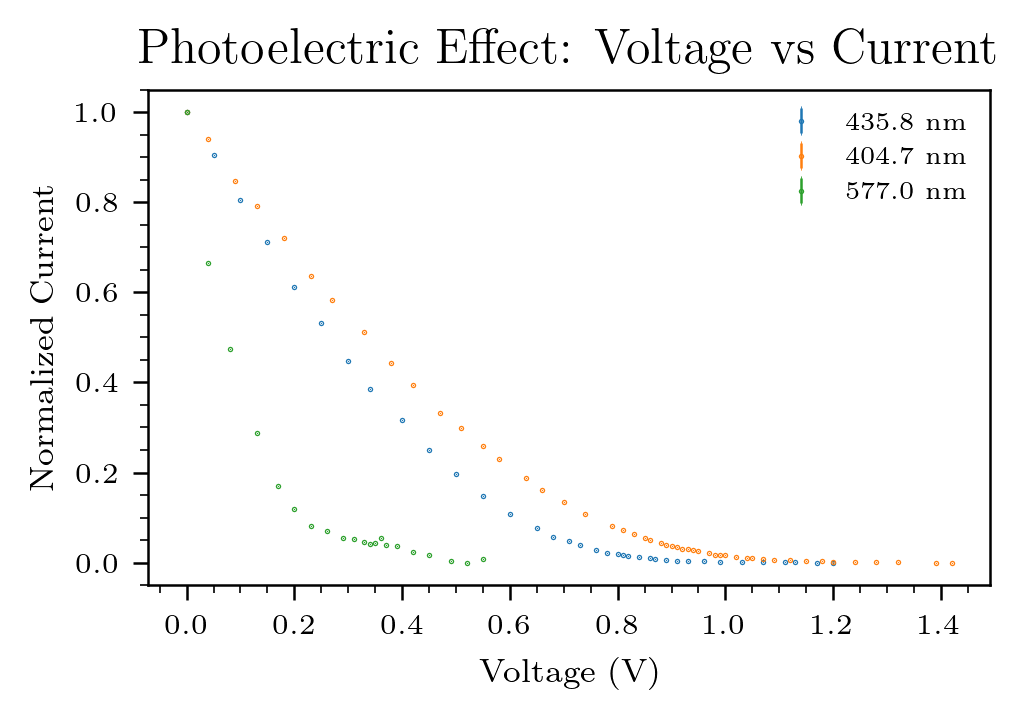

In [86]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import csv

plt.style.use("./jlab.mplstyle")

def load_iv_data(filename):
    """Load a voltage/current CSV, merging repeated voltages into mean ± SEM.
    Uses the first two columns regardless of header names."""
    data_by_voltage = {}
    with open(filename, newline="") as f:
        reader = csv.reader(f)
        next(reader)  # skip header
        for row in reader:
            v, i = float(row[0]), float(row[1])
            data_by_voltage.setdefault(v, []).append(i)

    voltages = np.array(sorted(data_by_voltage.keys()))
    currents = np.array([np.mean(data_by_voltage[v]) for v in voltages])
    uncertainties = np.array([scipy.stats.sem(data_by_voltage[v]) for v in voltages])
    return voltages, currents, uncertainties

datasets = {
    "435.8 nm": load_iv_data("435.8.csv"),
    "404.7 nm": load_iv_data("404.7.csv"),
    "577.0 nm": load_iv_data("577+tape.csv"),
}

# Normalize currents and uncertainties to fraction of each dataset's max current
datasets = {
    label: (v, (i-i.min()) / (i.max()-i.min()), u / (i.max()-i.min()))
    for label, (v, i, u) in datasets.items()
}

# Plot voltage vs current with errorbars
fig, ax = plt.subplots(figsize=(3.5, 2.5))
for label, (voltages, currents, uncertainties) in datasets.items():
    ax.errorbar(voltages, currents, yerr=uncertainties, fmt="o", capsize=0.1,markersize=0.3, label=label)
ax.set_xlabel("Voltage (V)")
ax.set_ylabel("Normalized Current")
ax.set_title("Photoelectric Effect: Voltage vs Current")
ax.legend()
plt.tight_layout()
plt.show()


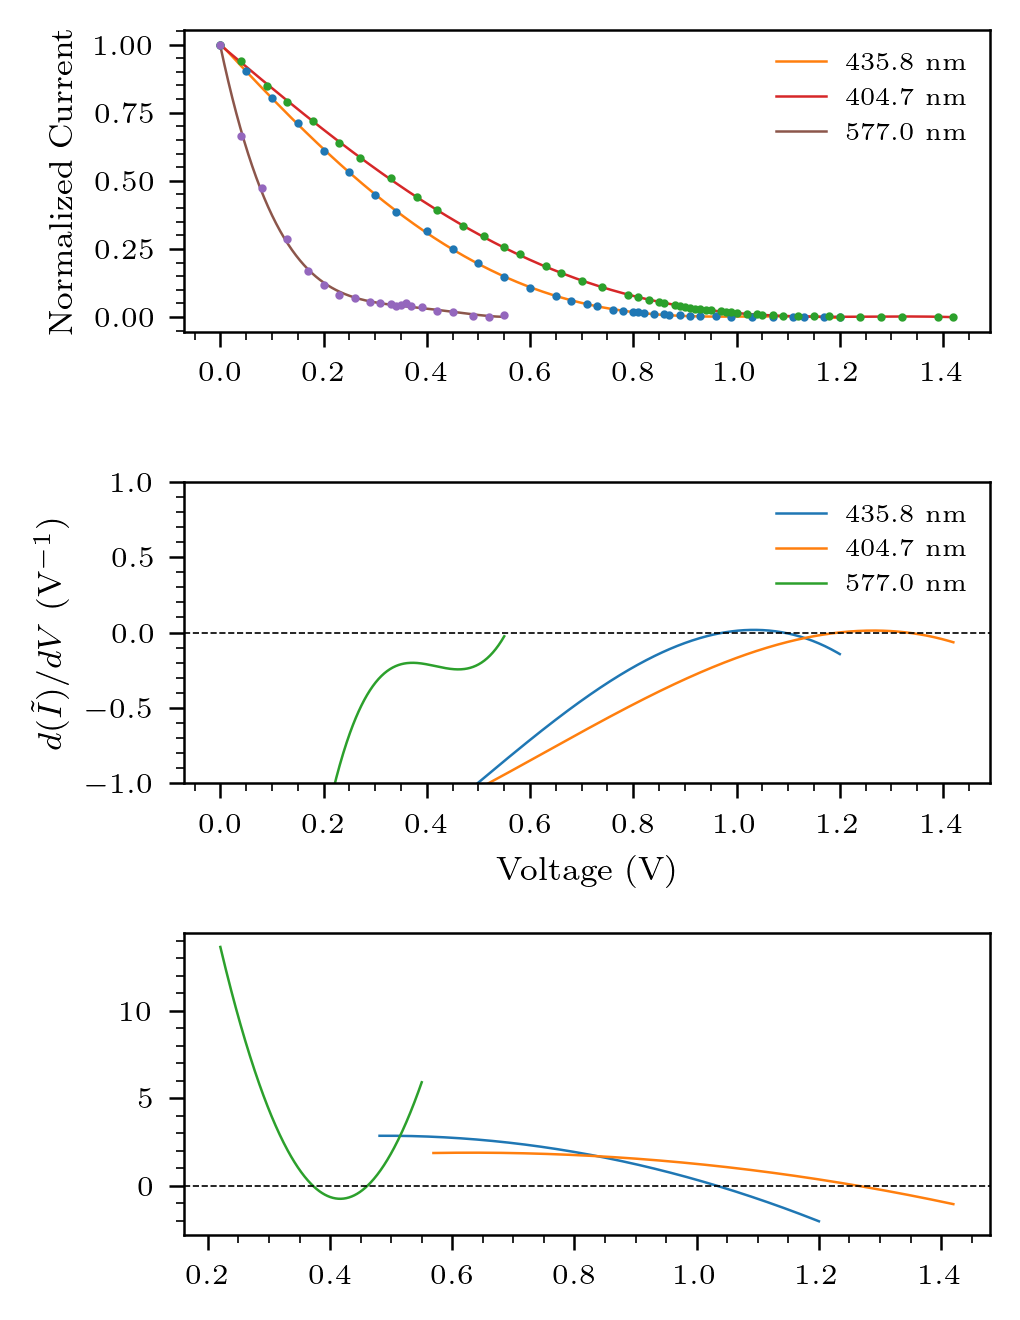

In [87]:
from scipy.interpolate import UnivariateSpline

k = 4
smoothing = 1

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=False, figsize=(3.5, 4.5))

for label, (voltages, currents, uncertainties) in datasets.items():
    w = np.where(uncertainties > 0, 1 / uncertainties, 1.0)

    us = UnivariateSpline(voltages, currents, w=w, k=k, s=smoothing)
    us_deriv = us.derivative()
    us_2_deriv = us_deriv.derivative()

    v_fine = np.linspace(voltages[0], voltages[-1], 500)

    ax1.errorbar(voltages, currents, yerr=uncertainties, fmt="o", markersize=1)
    ax1.plot(v_fine, us(v_fine), label=label)
    ax2.plot(v_fine, us_deriv(v_fine), label=label)
    ax3.plot(v_fine[200:], us_2_deriv(v_fine[200:]), label=label)

ax2.axhline(0, color="k", linewidth=0.4, linestyle="--")
ax3.axhline(0, color="k", linewidth=0.4, linestyle="--")

ax1.set_ylabel("Normalized Current")
ax1.legend()

ax2.set_xlabel("Voltage (V)")
ax2.set_ylabel(r"$d(\tilde{I})/dV$ (V$^{-1}$)")
ax2.set_ylim(-1.0,1.0)
ax2.legend()

plt.tight_layout()
plt.show()


435.8 nm: V_stop = 1.0340 V,  f = 6.8791e+14 Hz
404.7 nm: V_stop = 1.2652 V,  f = 7.4078e+14 Hz
577.0 nm: V_stop = 0.3722 V,  f = 5.1957e+14 Hz

h/e   = 4.0103e-15 V·s
h     = 6.4244e-34 J·s  (true: 6.626×10⁻³⁴)
δh    = 1.3465e-35 J·s


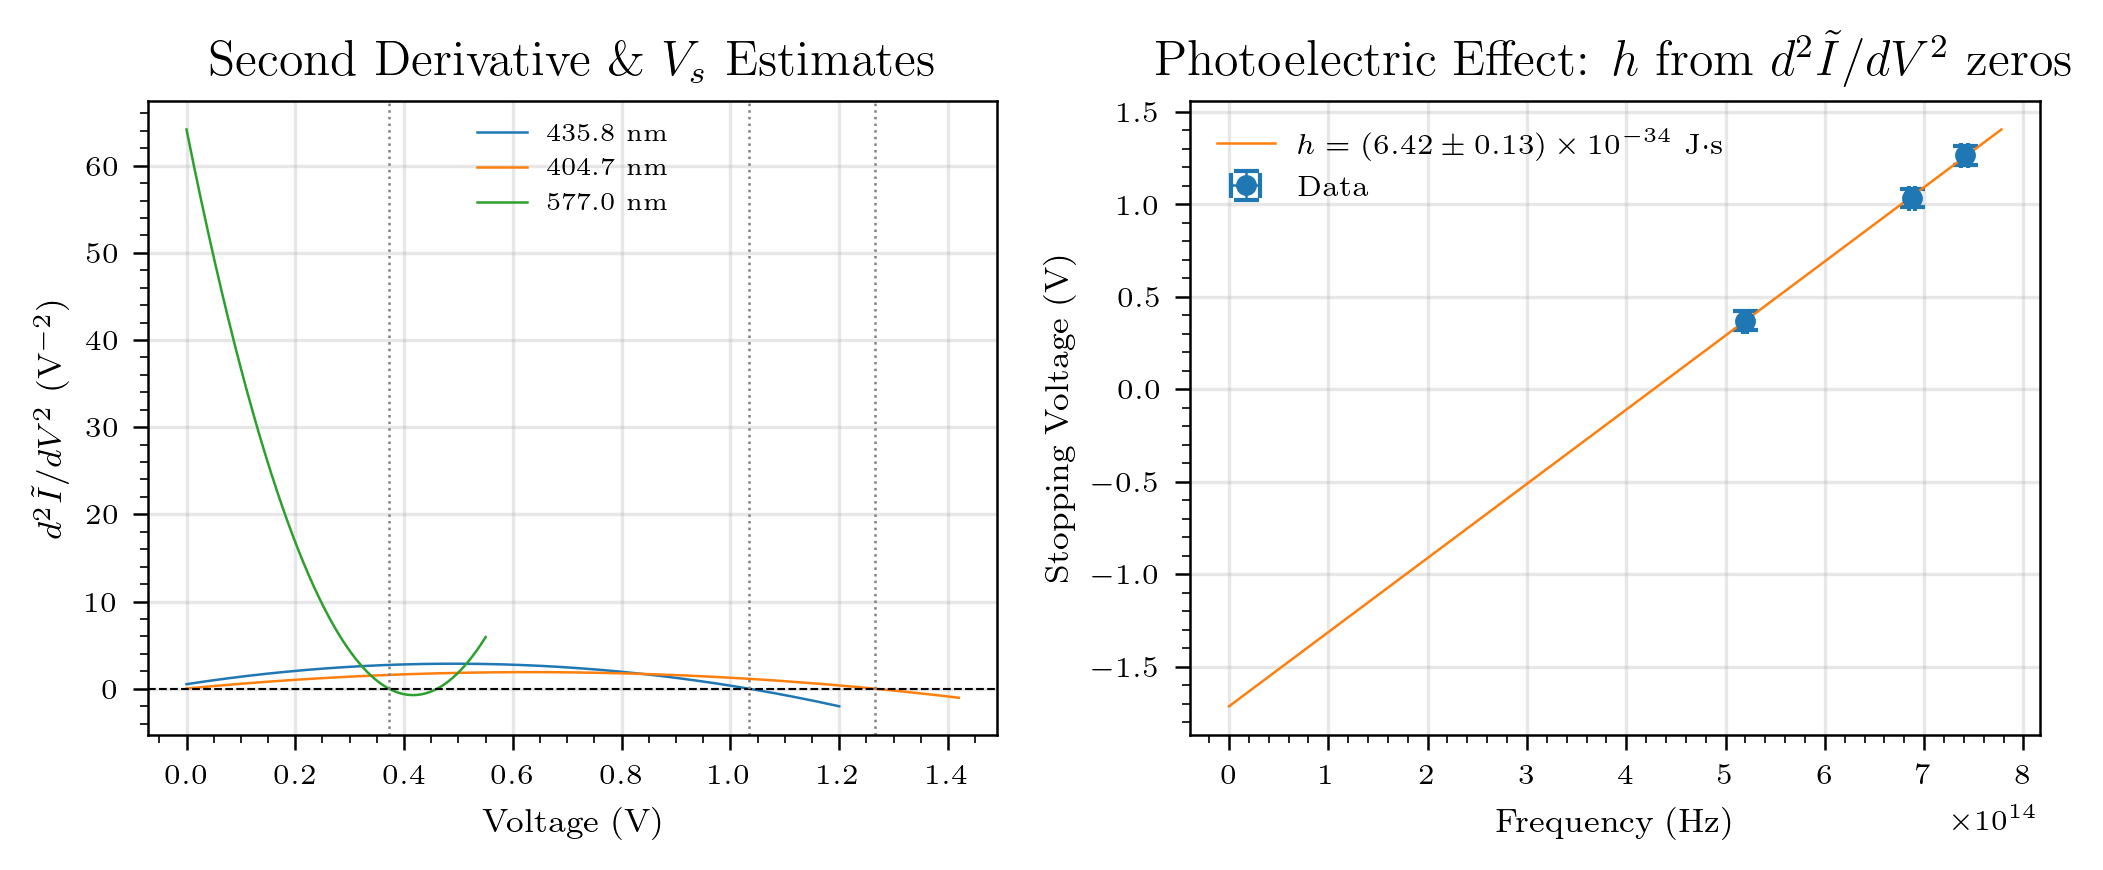

In [88]:
import warnings
from scipy.interpolate import UnivariateSpline
from scipy.optimize import brentq
with warnings.catch_warnings():
    warnings.simplefilter("ignore", DeprecationWarning)
    from scipy.odr import ODR, Model, RealData

c = 299792458       # m/s
wave_unc_nm = 2     # nm wavelength uncertainty
e = 1.602e-19       # C

V_stops_d2     = []
V_stops_d2_unc = []
freqs           = []
freqs_unc       = []

for label, (voltages, currents, uncertainties) in datasets.items():
    wl_nm = label.split()[0]
    freq  = c / (float(wl_nm) * 1e-9)
    f_unc = (c / (float(wl_nm) * 1e-9)**2) * wave_unc_nm * 1e-9

    w  = np.where(uncertainties > 0, 1 / uncertainties, 1.0)
    us = UnivariateSpline(voltages, currents, w=w, k=k, s=smoothing)
    d2 = us.derivative().derivative()

    # Find the leftmost sign change in the upper 60% of the voltage range
    v_lo   = voltages[0] + 0.4 * (voltages[-1] - voltages[0])
    v_search = np.linspace(v_lo, voltages[-1], 2000)
    d2_vals  = d2(v_search)
    sign_change_idx = np.where(np.diff(np.sign(d2_vals)))[0]

    if sign_change_idx.size > 0:
        i = sign_change_idx[0]
        V_stop = brentq(d2, v_search[i], v_search[i + 1])
    else:
        V_stop = np.nan

    V_stops_d2.append(V_stop)
    V_stops_d2_unc.append(0.05)   # placeholder
    freqs.append(freq)
    freqs_unc.append(f_unc)
    print(f"{label}: V_stop = {V_stop:.4f} V,  f = {freq:.4e} Hz")

V_stops_d2     = np.array(V_stops_d2)
V_stops_d2_unc = np.array(V_stops_d2_unc)
freqs          = np.array(freqs)
freqs_unc      = np.array(freqs_unc)

# --- ODR linear fit: V_stop = (h/e) * f + phi ---
def linear_odr(beta, x):
    return beta[0] * x + beta[1]

with warnings.catch_warnings():
    warnings.simplefilter("ignore", DeprecationWarning)
    data       = RealData(freqs, V_stops_d2, sx=freqs_unc, sy=V_stops_d2_unc)
    odr_result = ODR(data, Model(linear_odr), beta0=[3.8e-15, -1.0]).run()

m, b   = odr_result.beta
m_err  = odr_result.sd_beta[0]
h_est  = e * m
h_err  = e * m_err

print(f"\nh/e   = {m:.4e} V·s")
print(f"h     = {h_est:.4e} J·s  (true: 6.626×10⁻³⁴)")
print(f"δh    = {h_err:.4e} J·s")

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))

# Left: 2nd derivatives with stopping-voltage estimates marked
for label, (voltages, currents, uncertainties) in datasets.items():
    w      = np.where(uncertainties > 0, 1 / uncertainties, 1.0)
    us     = UnivariateSpline(voltages, currents, w=w, k=k, s=smoothing)
    d2     = us.derivative().derivative()
    v_plot = np.linspace(voltages[0], voltages[-1], 500)
    ax1.plot(v_plot, d2(v_plot), label=label)

ax1.axhline(0, color="k", linewidth=0.5, linestyle="--")
for V_s in V_stops_d2:
    ax1.axvline(V_s, color="gray", linewidth=0.6, linestyle=":")
ax1.set_xlabel("Voltage (V)")
ax1.set_ylabel(r"$d^2\tilde{I}/dV^2$ (V$^{-2}$)")
ax1.set_title(r"Second Derivative \& $V_s$ Estimates")
ax1.legend(fontsize=6)
ax1.grid(True, alpha=0.3)

# Right: V_stop vs frequency with ODR fit
ax2.errorbar(freqs, V_stops_d2, yerr=V_stops_d2_unc, xerr=freqs_unc,
             fmt="o", markersize=4, capsize=3, label="Data")
f_fit = np.linspace(0, max(freqs) * 1.05, 200)
ax2.plot(f_fit, m * f_fit + b,
         label=rf"$h = ({h_est/1e-34:.2f} \pm {h_err/1e-34:.2f}) \times 10^{{-34}}$ J·s")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Stopping Voltage (V)")
ax2.set_title(r"Photoelectric Effect: $h$ from $d^2\tilde{I}/dV^2$ zeros")
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
